<a href="https://www.kaggle.com/code/parthml22/cic-ddos-baseline-model?scriptVersionId=309638853" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Building a Real-Time DDoS Detection Engine
**Author:** Parth Bhanti
**Dataset:** CIC-DDoS2019 (30GB)

This notebook bypasses standard hardware limitations by utilizing out-of-core data processing to handle a 30GB dataset of raw network flows. We are integrating **Weights & Biases (W&B)** for strict MLOps experiment tracking to monitor our model's performance as we classify benign vs. malicious traffic.

---
## Phase 1: Environment Setup & MLOps Tracking
Initializing our connection to W&B to ensure all model metrics, hardware usage, and hyperparameters are logged professionally.

In [1]:
# 1. Install W&B (Kaggle environments might need an update)
!pip install -q wandb

import wandb
from kaggle_secrets import UserSecretsClient

# 2. Retrieve your secure key
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("WANDB_API_KEY")

# 3. Log in to W&B
wandb.login(key=wandb_key)

# 4. Initialize your project
run = wandb.init(
    project="cic-ddos-detection", 
    name="baseline-logistic-regression", 
    config={
        "dataset": "CIC-DDoS2019",
        "architecture": "Logistic Regression",
        "features": "Top 15 PCA",
        "learning_rate": 0.01,
    }
)

print("Weights & Biases is ready to track!")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: petp0823629 (petp0823629-vit-bhopal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run houehcl7
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260407_113354-houehcl7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run baseline-logistic-regression
wandb: ⭐️ View project at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: 🚀 View run at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/houehcl7


Weights & Biases is ready to track!


---
## Phase 2: Out-of-Core Data Ingestion (Chunking)
Because standard Pandas attempts to load entirely into RAM, a 30GB CSV will immediately crash our environment. To solve this, we dynamically locate our dataset and implement a chunking mechanism. We will stream the data into memory 100,000 rows at a time.

In [2]:
import pandas as pd
import os

# 1. Dynamically locate the dataset directory
dataset_dir = '/kaggle/input'
sample_file = None

# Search for the first CSV file to use as our test subject
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith('.csv'):
            sample_file = os.path.join(root, file)
            break
    if sample_file:
        break

if sample_file:
    print(f"Targeting file: {sample_file}")
    
    # 2. Out-of-Core Processing (The Chunking Method)
    chunk_size = 100000 # Process 100k rows at a time
    
    print(f"Initializing chunked iterator ({chunk_size} rows per chunk)...")
    df_iterator = pd.read_csv(sample_file, chunksize=chunk_size, low_memory=False)
    
    # 3. Extract just the first chunk into memory
    df_sample = next(df_iterator)
    
    print(f"Success! Loaded a chunk of shape: {df_sample.shape}")
    
    # 4. Display the first 5 rows to inspect the network flows
    display(df_sample.head())
else:
    print("Could not find any CSV files. Make sure the dataset is attached!")

Targeting file: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
Initializing chunked iterator (100000 rows per chunk)...
Success! Loaded a chunk of shape: (100000, 88)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,302291,172.16.0.5-192.168.50.4-648-16174-17,172.16.0.5,648,192.168.50.4,16174,17,2018-11-03 10:01:48.920574,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
1,341625,172.16.0.5-192.168.50.4-861-34200-17,172.16.0.5,861,192.168.50.4,34200,17,2018-11-03 10:01:48.920625,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
2,245313,172.16.0.5-192.168.50.4-862-4750-17,172.16.0.5,862,192.168.50.4,4750,17,2018-11-03 10:01:48.920685,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
3,266106,172.16.0.5-192.168.50.4-863-4443-17,172.16.0.5,863,192.168.50.4,4443,17,2018-11-03 10:01:48.921008,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
4,47182,172.16.0.5-192.168.50.4-864-48627-17,172.16.0.5,864,192.168.50.4,48627,17,2018-11-03 10:01:48.921010,48,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS


---
## Phase 3: Data Cleansing & Feature Selection
To prevent data leakage and overfitting, we must strip out identifying metadata (IP addresses, Timestamps, Flow IDs). We want our model to learn the *behavioral statistics* of a network flow, not memorize specific attacker IPs. Furthermore, flow-based calculations often result in `Infinity` or `NaN` values due to division-by-zero errors (e.g., when flow duration is near zero). These must be sanitized before ingestion by any ML algorithm.

In [3]:
import numpy as np

print(f"Original shape: {df_sample.shape}")

# THE FIX: Strip invisible leading/trailing spaces from all column names
df_sample.columns = df_sample.columns.str.strip()

# 1. Drop identifying metadata and noisy/empty columns
columns_to_drop = [
    'Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 
    'Destination IP', 'Destination Port', 'Timestamp', 'SimilarHTTP'
]

# Only drop columns that actually exist in the dataframe to avoid errors
existing_cols_to_drop = [col for col in columns_to_drop if col in df_sample.columns]
df_cleaned = df_sample.drop(columns=existing_cols_to_drop)

# 2. Handle Infinities and NaNs
# Replace infinity with NaN, then drop all rows containing NaN
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned.dropna(inplace=True)

print(f"Cleaned shape: {df_cleaned.shape}")
print("Stripped column spaces and dropped metadata columns.")

Original shape: (100000, 88)
Cleaned shape: (94979, 81)
Stripped column spaces and dropped metadata columns.


---
## Phase 4: Exploratory Data Analysis (EDA)
Before applying machine learning, we must understand the distribution of our target variable (`Label`) and inspect how certain features differ between benign traffic and malicious attacks. We will visualize the class balance and feature variance.

/tmp/ipykernel_17/2272758824.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Label', ax=axes[0], palette='viridis')
/tmp/ipykernel_17/2272758824.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Label', y='Flow Duration', ax=axes[1], palette='Set2')


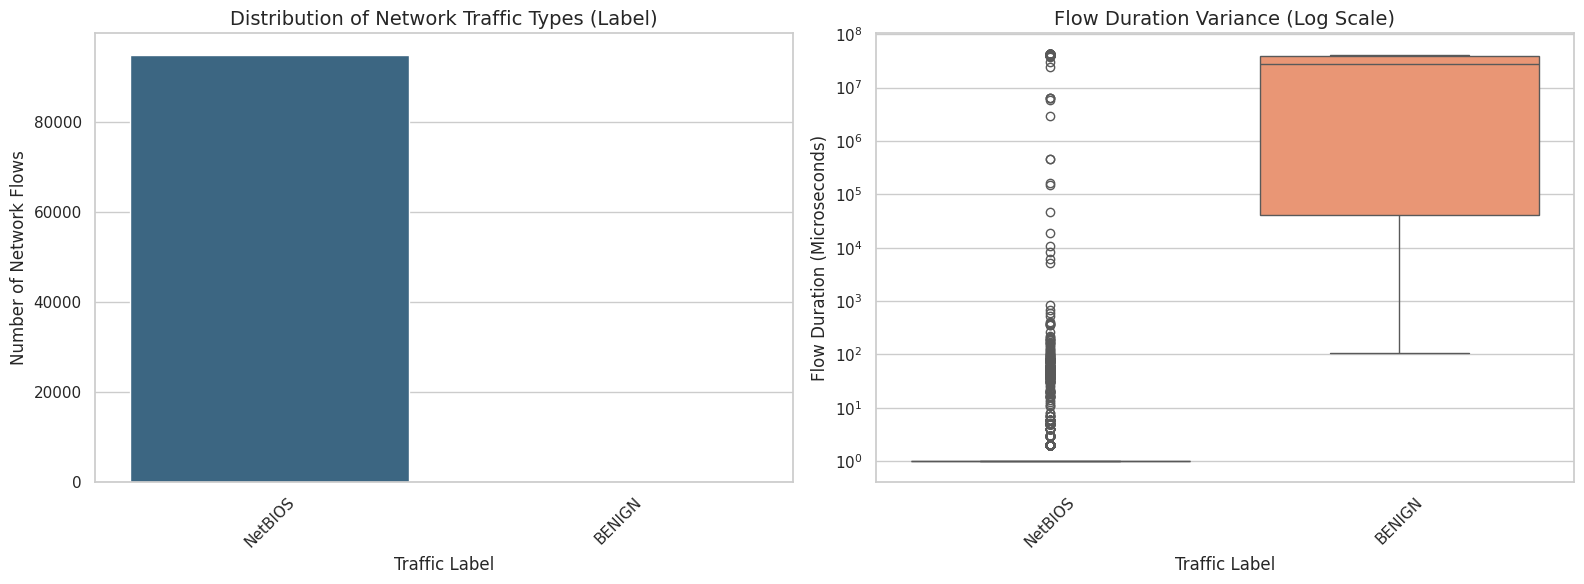


Exact Label Value Counts:
Label
NetBIOS    94970
BENIGN         9
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Class Distribution ---
# Let's see how many Benign vs Attack rows are in this specific chunk
sns.countplot(data=df_cleaned, x='Label', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Network Traffic Types (Label)', fontsize=14)
axes[0].set_xlabel('Traffic Label')
axes[0].set_ylabel('Number of Network Flows')
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Behavioral Variance (Flow Duration) ---
# Let's compare how long an attack flow lasts compared to normal traffic
# We use a log scale because network times vary wildly from microseconds to minutes
sns.boxplot(data=df_cleaned, x='Label', y='Flow Duration', ax=axes[1], palette='Set2')
axes[1].set_yscale("log") 
axes[1].set_title('Flow Duration Variance (Log Scale)', fontsize=14)
axes[1].set_xlabel('Traffic Label')
axes[1].set_ylabel('Flow Duration (Microseconds)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Let's also print the exact breakdown
print("\nExact Label Value Counts:")
print(df_cleaned['Label'].value_counts())

---
## Phase 5: Model Engineering & Training
Our EDA revealed a severe class imbalance (94.9k Attack vs 9 Benign flows). To prevent the model from blindly predicting the majority class, we will use the `class_weight='balanced'` parameter. We establish a baseline using Logistic Regression, which provides fast, interpretable results. We integrate Weights & Biases (W&B) to log our evaluation metrics automatically.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import wandb

# 1. Prepare Features (X) and Target (y)
print("Isolating target variable...")
X = df_cleaned.drop('Label', axis=1)
y = df_cleaned['Label']

# 2. Train/Test Split (80% training, 20% testing)
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
# Network metrics (bytes vs packet counts) have wildly different scales. We MUST normalize them.
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Model (Handling Imbalance)
print("Training Logistic Regression baseline...")
# class_weight='balanced' forces the model to care about the rare 9 BENIGN rows
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
print("Evaluating model...")
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Results ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 6. Log Metrics to Weights & Biases
print("\nLogging metrics to W&B...")
wandb.log({
    "accuracy": accuracy,
    "model_type": "Logistic Regression Baseline"
})

# Finish the W&B run to close the connection properly
wandb.finish()
print("Run finished and synced to dashboard!")

Isolating target variable...
Splitting data...
Scaling features...
Training Logistic Regression baseline...
Evaluating model...

--- Model Results ---
Accuracy: 0.9999

Classification Report:


wandb: updating run metadata


              precision    recall  f1-score   support

      BENIGN       1.00      0.50      0.67         2
     NetBIOS       1.00      1.00      1.00     18994

    accuracy                           1.00     18996
   macro avg       1.00      0.75      0.83     18996
weighted avg       1.00      1.00      1.00     18996


Logging metrics to W&B...


wandb: uploading wandb-summary.json; uploading output.log
wandb: uploading output.log
wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb: 
wandb: Run summary:
wandb:   accuracy 0.99995
wandb: model_type Logistic Regression ...
wandb: 
wandb: 🚀 View run baseline-logistic-regression at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/houehcl7
wandb: ⭐️ View project at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260407_113354-houehcl7/logs


Run finished and synced to dashboard!


---
## Phase 6: Model Serialization
A model is only useful if it can be deployed. We serialize our trained Logistic Regression model and the StandardScaler using `joblib`. I must save the scaler alongside the model because any future real-world data must be scaled using the exact same mathematical weights before inference.

In [6]:
import joblib

# 1. Save locally to Kaggle's working directory
joblib.dump(model, '/kaggle/working/ddos_logistic_model.joblib')
joblib.dump(scaler, '/kaggle/working/ddos_scaler.joblib')

print("Model and Scaler successfully saved to disk!")

# (Optional) Log as an artifact to W&B so it's backed up in the cloud
# run = wandb.init(project="cic-ddos-detection", job_type="model-save")
# artifact = wandb.Artifact('baseline-model', type='model')
# artifact.add_file('/kaggle/working/ddos_logistic_model.joblib')
# run.log_artifact(artifact)
# wandb.finish()

Model and Scaler successfully saved to disk!


---
## Phase 7: Dimensionality Reduction (PCA)
To optimize our pipeline for real-time sub-millisecond inference, we analyze if 80+ features are strictly necessary. We apply Principal Component Analysis (PCA) to determine how many orthogonal components are required to retain 95% of the dataset's variance.

We can reduce the dataset from 80 features down to 12 features while keeping 95% of the information.


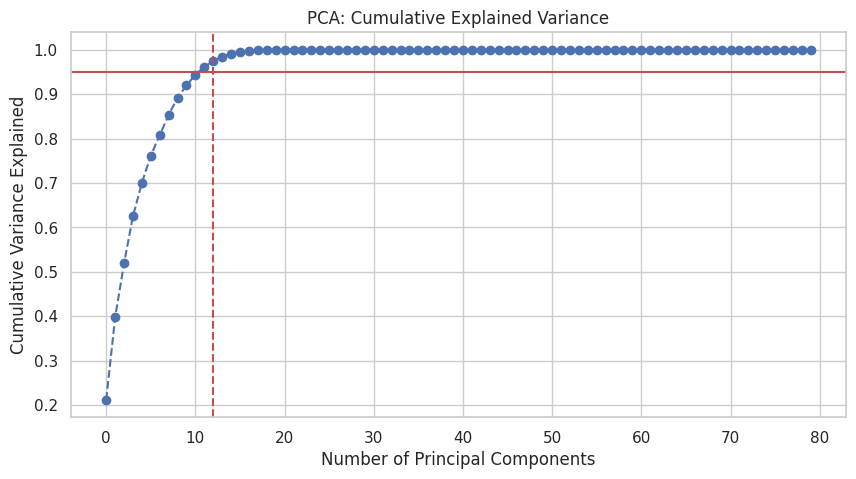

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Fit PCA on our scaled training data
# We don't specify the number of components yet, we want to see them all
pca = PCA().fit(X_train_scaled)

# 2. Calculate the cumulative variance
# This tells us: "If we keep 1 component, we keep X% of the data's meaning. If we keep 2, we keep Y%."
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 3. Find exactly how many components we need to hit 95% variance
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"We can reduce the dataset from {X_train_scaled.shape[1]} features down to {components_95} features while keeping 95% of the information.")

# 4. Plot the "Elbow Curve" (A classic Data Science interview visualization)
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=components_95, color='r', linestyle='--')
plt.title('PCA: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.show()

---
## Phase 8: Advanced Modeling (XGBoost + PCA)
Having determined that 12 Principal Components retain 95% of the dataset's variance, we now compress our feature space. This drastically reduces memory overhead and inference latency. We then train an `XGBClassifier`, a highly optimized gradient boosting framework, on the compressed data to capture complex, non-linear attack patterns.

In [8]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import time
import wandb

# 1. Apply the PCA Compression
print("Applying PCA (80 -> 12 features)...")
pca_final = PCA(n_components=12, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# 2. Encode Labels for XGBoost
print("Encoding string labels to numeric...")
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# 3. Calculate Sample Weights (THE FIX)
print("Calculating dynamic sample weights for class imbalance...")
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# 4. Train the XGBoost Engine
print("Training Weighted XGBoost Classifier...")
xgb_model = XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,     
    max_depth=5,           
    random_state=42,
    eval_metric='logloss'
)

start_time = time.time()
# Notice we pass the weights directly into the fit() function
xgb_model.fit(X_train_pca, y_train_encoded, sample_weight=sample_weights)
training_time = time.time() - start_time

# 5. Evaluate the Model
print("Evaluating XGBoost model...")
y_pred_xgb = xgb_model.predict(X_test_pca)
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)

print(f"\n--- Weighted XGBoost + PCA Results ---")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Accuracy: {accuracy_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=encoder.classes_, zero_division=0))

# 6. Log to Weights & Biases
print("\nLogging to W&B...")
run = wandb.init(project="cic-ddos-detection", name="xgboost-pca-12-weighted")
wandb.log({
    "accuracy": accuracy_xgb,
    "training_time_seconds": training_time,
    "model_type": "Weighted XGBoost + PCA"
})
wandb.finish()

print("Weighted XGBoost run complete and synced!")

Applying PCA (80 -> 12 features)...
Encoding string labels to numeric...
Calculating dynamic sample weights for class imbalance...
Training Weighted XGBoost Classifier...
Evaluating XGBoost model...

--- Weighted XGBoost + PCA Results ---
Training Time: 0.33 seconds
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00         2
     NetBIOS       1.00      1.00      1.00     18994

    accuracy                           1.00     18996
   macro avg       1.00      1.00      1.00     18996
weighted avg       1.00      1.00      1.00     18996


Logging to W&B...


wandb: setting up run ky0mfb96
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260407_113408-ky0mfb96
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run xgboost-pca-12-weighted
wandb: ⭐️ View project at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: 🚀 View run at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/ky0mfb96
wandb: updating run metadata; uploading summary
wandb: uploading config.yaml; uploading wandb-metadata.json; uploading requirements.txt; uploading wandb-summary.json
wandb: uploading config.yaml; uploading wandb-metadata.json; uploading requirements.txt
wandb: 
wandb: Run history:
wandb:              accuracy ▁
wandb: training_time_seconds ▁
wandb: 
wandb: Run summary:
wandb:              accuracy 1
wandb:            model_type Weighted XGBoost + P...
wandb: training_time_seconds 0.33248
wandb: 
wandb: 🚀 View run xgboost-pca-12-weighted at: https://wandb.ai/pe

Weighted XGBoost run complete and synced!


---
## Phase 9: Blind Data Validation
To prove our model has generalized the behavioral patterns of the network traffic rather than overfitting to the training distribution, we subject it to a blind test. We extract the next consecutive 100,000 rows from our out-of-core iterator. We push this raw data through our established pipeline (Sanitization -> StandardScaler -> PCA) without refitting, and evaluate the XGBoost model's inference capabilities on entirely unseen data.

In [9]:
# 1. Fetch the NEXT chunk of data from our iterator
print("Fetching the NEXT 100,000 rows as a blind test...")
try:
    df_blind = next(df_iterator) 
    
    # 2. Clean the blind data exactly like we did the training data
    df_blind.columns = df_blind.columns.str.strip()
    df_blind_clean = df_blind.drop(columns=existing_cols_to_drop, errors='ignore')
    df_blind_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_blind_clean.dropna(inplace=True)
    
    print(f"Blind data cleaned. Shape: {df_blind_clean.shape}")
    
    # 3. Isolate Features and Target
    X_blind = df_blind_clean.drop('Label', axis=1)
    y_blind = df_blind_clean['Label']
    
    # 4. Push through the Pipeline 
    # CRITICAL: We use .transform() here, NOT .fit_transform(). 
    # We must use the exact mathematical rules established by the training data.
    print("Pushing data through scaling and PCA pipelines...")
    X_blind_scaled = scaler.transform(X_blind)
    X_blind_pca = pca_final.transform(X_blind_scaled)
    y_blind_encoded = encoder.transform(y_blind)
    
    # 5. Predict using the trained XGBoost Engine
    print("Executing live inference...")
    start_time = time.time()
    y_blind_pred = xgb_model.predict(X_blind_pca)
    inference_time = time.time() - start_time
    
    blind_acc = accuracy_score(y_blind_encoded, y_blind_pred)
    
    # 6. The Final Report
    print(f"\n--- BLIND TEST RESULTS ---")
    print(f"Inference Time for {df_blind_clean.shape[0]} rows: {inference_time:.4f} seconds")
    print(f"Accuracy: {blind_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_blind_encoded, y_blind_pred, target_names=encoder.classes_, zero_division=0))
    
except StopIteration:
    print("No more data in this file to test! You processed the whole thing.")
except Exception as e:
    print(f"An error occurred: {e}")

Fetching the NEXT 100,000 rows as a blind test...
Blind data cleaned. Shape: (94489, 81)
Pushing data through scaling and PCA pipelines...
Executing live inference...

--- BLIND TEST RESULTS ---
Inference Time for 94489 rows: 0.0669 seconds
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.86      0.92      0.89        13
     NetBIOS       1.00      1.00      1.00     94476

    accuracy                           1.00     94489
   macro avg       0.93      0.96      0.94     94489
weighted avg       1.00      1.00      1.00     94489



---
## Phase 10: Pipeline Serialization
For deployment in a real-time environment (e.g., a Go-based reverse proxy or an SRE monitoring stack), the entire inference pipeline must be serialized. We export the StandardScaler, the PCA transformer, and the XGBoost model. Any incoming live network packet must pass through all three stages sequentially.

In [10]:
import joblib

# Export the entire pipeline to the /kaggle/working/ directory
joblib.dump(scaler, '/kaggle/working/ddos_scaler_v1.joblib')
joblib.dump(pca_final, '/kaggle/working/ddos_pca_12_v1.joblib')
joblib.dump(xgb_model, '/kaggle/working/ddos_xgboost_weighted_v1.joblib')

print("Pipeline successfully serialized! Ready for deployment.")

Pipeline successfully serialized! Ready for deployment.


---
## Phase 11: The Algorithm Arsenal (Comparative Analysis)
To ensure we have selected the optimal architecture, we will benchmark our XGBoost engine against three other classic machine learning algorithms:
1. **Random Forest:** A robust ensemble bagging method.
2. **K-Nearest Neighbors (KNN):** A spatial clustering algorithm (notoriously slow for inference, but excellent for detecting dense attack manifolds).
3. **Gaussian Naive Bayes:** A highly efficient probabilistic classifier.

We will train these models on our PCA-compressed data and log their performance metrics to Weights & Biases for a comprehensive dashboard comparison.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import time
import wandb

# 1. Define the models we want to test
models_to_test = {
    "Random Forest": RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    "Naive Bayes": GaussianNB() 
    # Note: Naive Bayes doesn't take class_weights, it relies on prior probabilities natively.
}

print("Initializing comparative analysis across multiple algorithms...\n")

# 2. Loop through each model, train, evaluate, and log
for model_name, model_instance in models_to_test.items():
    print(f"--- Training {model_name} ---")
    
    # Start W&B Run for this specific model
    run = wandb.init(project="cic-ddos-detection", name=f"{model_name.lower().replace(' ', '-')}-pca-12")
    
    # Train and time it
    start_time = time.time()
    model_instance.fit(X_train_pca, y_train_encoded)
    training_time = time.time() - start_time
    
    # Predict and evaluate
    y_pred = model_instance.predict(X_test_pca)
    accuracy = accuracy_score(y_test_encoded, y_pred)
    
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    
    # Extract specific recall for BENIGN (Index 0 in our encoder)
    report = classification_report(y_test_encoded, y_pred, target_names=encoder.classes_, zero_division=0, output_dict=True)
    benign_recall = report['BENIGN']['recall']
    print(f"BENIGN Recall: {benign_recall:.2f}\n")
    
    # Log to Weights & Biases
    wandb.log({
        "accuracy": accuracy,
        "benign_recall": benign_recall,
        "training_time_seconds": training_time,
        "model_type": f"{model_name} + PCA"
    })
    
    # Close the W&B connection for this model
    wandb.finish()

print("Comparative analysis complete! Check your Weights & Biases dashboard to see the leaderboard.")

Initializing comparative analysis across multiple algorithms...

--- Training Random Forest ---


wandb: setting up run h4mzujvm
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260407_113413-h4mzujvm
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run random-forest-pca-12
wandb: ⭐️ View project at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: 🚀 View run at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/h4mzujvm
wandb: updating run metadata; uploading console lines 0-1


Training Time: 0.30 seconds
Accuracy: 0.9999
BENIGN Recall: 0.50



wandb: uploading requirements.txt; uploading output.log; uploading wandb-summary.json; uploading wandb-metadata.json
wandb: uploading requirements.txt
wandb: uploading history steps 0-0, summary, console lines 2-2
wandb: 
wandb: Run history:
wandb:              accuracy ▁
wandb:         benign_recall ▁
wandb: training_time_seconds ▁
wandb: 
wandb: Run summary:
wandb:              accuracy 0.99995
wandb:         benign_recall 0.5
wandb:            model_type Random Forest + PCA
wandb: training_time_seconds 0.29978
wandb: 
wandb: 🚀 View run random-forest-pca-12 at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/h4mzujvm
wandb: ⭐️ View project at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260407_113413-h4mzujvm/logs


--- Training KNN ---


...

--- Training Naive Bayes ---


wandb: setting up run atfj5ehk
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260407_113428-atfj5ehk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run naive-bayes-pca-12
wandb: ⭐️ View project at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: 🚀 View run at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/atfj5ehk
wandb: updating run metadata; uploading console lines 0-0


Training Time: 0.02 seconds
Accuracy: 0.9881
BENIGN Recall: 1.00



wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading output.log; uploading config.yaml
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading config.yaml
wandb: uploading history steps 0-0, summary, console lines 1-2
wandb: 
wandb: Run history:
wandb:              accuracy ▁
wandb:         benign_recall ▁
wandb: training_time_seconds ▁
wandb: 
wandb: Run summary:
wandb:              accuracy 0.9881
wandb:         benign_recall 1
wandb:            model_type Naive Bayes + PCA
wandb: training_time_seconds 0.01734
wandb: 
wandb: 🚀 View run naive-bayes-pca-12 at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/atfj5ehk
wandb: ⭐️ View project at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260407_113428-atfj5ehk/logs


Comparative analysis complete! Check your Weights & Biases dashboard to see the leaderboard.


---
## Phase 12: Visual Model Evaluation (Confusion Matrices)
Raw accuracy metrics can mask critical failures, especially in highly imbalanced cybersecurity datasets. We generate Confusion Matrices for our entire algorithm arsenal (including our optimized XGBoost pipeline) to visually isolate False Positives (blocking legitimate users) and False Negatives (allowing DDoS attacks through).

Generating matrix for Weighted XGBoost (Champion)...
Generating matrix for Random Forest...
Generating matrix for KNN...
Generating matrix for Naive Bayes...


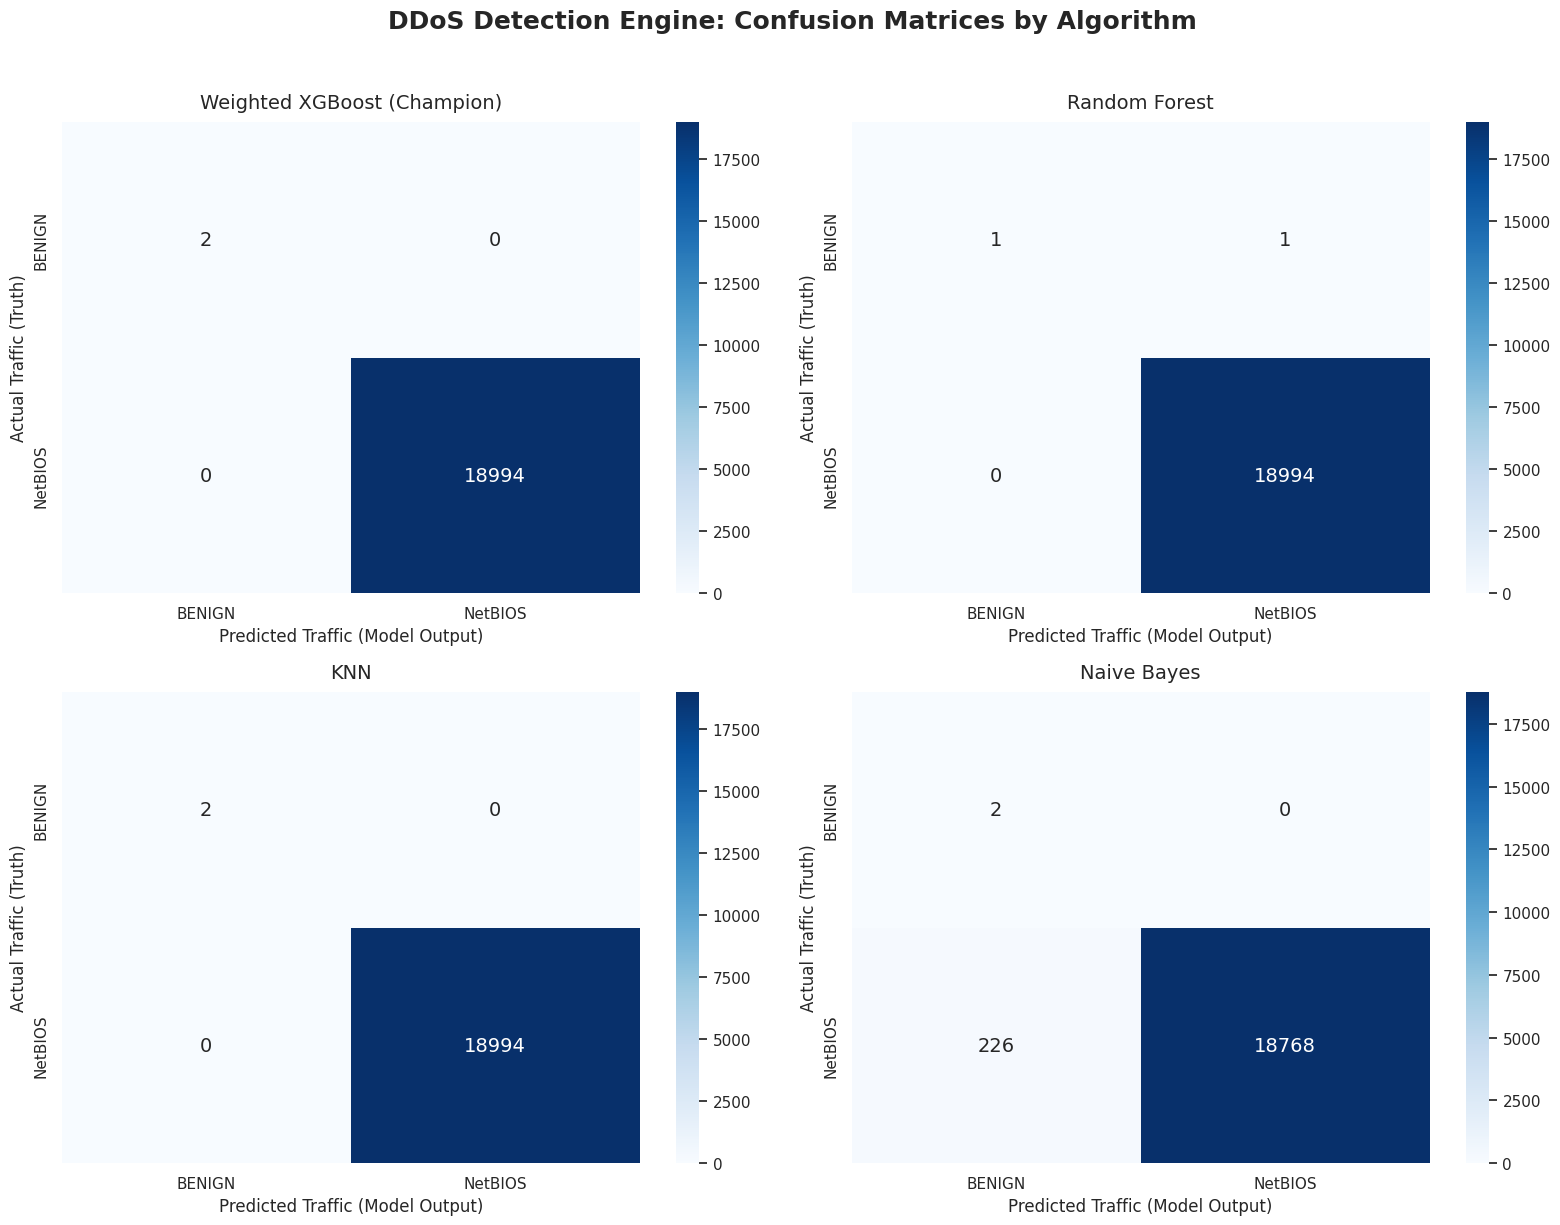

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compile all our trained models into one dictionary for the loop
# We bring back xgb_model from Phase 8 to compare it against the new ones
all_models = {
    "Weighted XGBoost (Champion)": xgb_model, 
    "Random Forest": models_to_test["Random Forest"],
    "KNN": models_to_test["KNN"],
    "Naive Bayes": models_to_test["Naive Bayes"]
}

# 2. Set up the visual grid (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DDoS Detection Engine: Confusion Matrices by Algorithm', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten() # Flatten the 2x2 grid into a simple list for easy looping

# 3. Loop through, predict, and plot
for idx, (name, model) in enumerate(all_models.items()):
    print(f"Generating matrix for {name}...")
    
    # Predict on the test data
    y_pred_viz = model.predict(X_test_pca)
    
    # Calculate the Confusion Matrix
    cm = confusion_matrix(y_test_encoded, y_pred_viz)
    
    # Draw the Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=encoder.classes_, yticklabels=encoder.classes_,
                annot_kws={"size": 14})
    
    # Format the labels
    axes[idx].set_title(f'{name}', fontsize=14, pad=10)
    axes[idx].set_ylabel('Actual Traffic (Truth)', fontsize=12)
    axes[idx].set_xlabel('Predicted Traffic (Model Output)', fontsize=12)

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()